STEP 1: Import Required Libraries

In [1]:
import cv2                          # OpenCV for image processing
import numpy as np                 # Numerical operations
import matplotlib.pyplot as plt    # Image display
import urllib.request              # For downloading the image
import ssl                         # To bypass SSL issues

STEP 2: Set Google Drive Direct Image URL

In [2]:
# Replace /view with /uc?export=download&id=FILE_ID

# Original URL: https://drive.google.com/file/d/1kWIx5TR65nuAIThAUgcn31ccBsOgVQW-/view?usp=sharing
image_url = "https://drive.google.com/uc?export=download&id=1kWIx5TR65nuAIThAUgcn31ccBsOgVQW-"

STEP 3: Download the image from URL

In [3]:
context = ssl._create_unverified_context()
resp = urllib.request.urlopen(image_url, context=context)
image_np = np.asarray(bytearray(resp.read()), dtype="uint8")

# Decode the image as a color image (BGR format in OpenCV)
image_bgr = cv2.imdecode(image_np, cv2.IMREAD_COLOR)

# Validate image
if image_bgr is None:
    raise Exception("❌ Image could not be loaded. Check the URL.")
else:
    print("✅ Image loaded successfully.")

✅ Image loaded successfully.


STEP 4: Convert BGR to RGB (for Matplotlib display)

In [4]:
# OpenCV loads images in BGR format by default, but matplotlib expects RGB
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

STEP 5: Extract R, G, B Channels

In [5]:
# Each channel represents the intensity of that color at each pixel

# Red channel: keep only red data, set green and blue to 0
red_channel = image_rgb.copy()
red_channel[:, :, 1] = 0  # Zero out green
red_channel[:, :, 2] = 0  # Zero out blue

# Green channel
green_channel = image_rgb.copy()
green_channel[:, :, 0] = 0  # Zero out red
green_channel[:, :, 2] = 0  # Zero out blue

# Blue channel
blue_channel = image_rgb.copy()
blue_channel[:, :, 0] = 0  # Zero out red
blue_channel[:, :, 1] = 0  # Zero out green

STEP 6: Convert to Grayscale

    Grayscale image contains no color, only intensity (0–255)
    Formula: Y = 0.299R + 0.587G + 0.114B

    # Importance:
    ➤ Reduces memory and computational load
    ➤ Ideal for edge detection, morphology, thresholding, etc.

In [6]:
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

STEP 7: Convert to Binary (Black & White)

    Binary images are strictly black or white (0 or 255)
    Formula: dst(x,y) = 255 if src(x,y) > T else 0
    Importance:
    ➤ Simplifies object detection
    ➤ Suitable for OCR and contour analysis

In [7]:
threshold_value = 127
_, binary = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)

STEP 8: Display All Variants

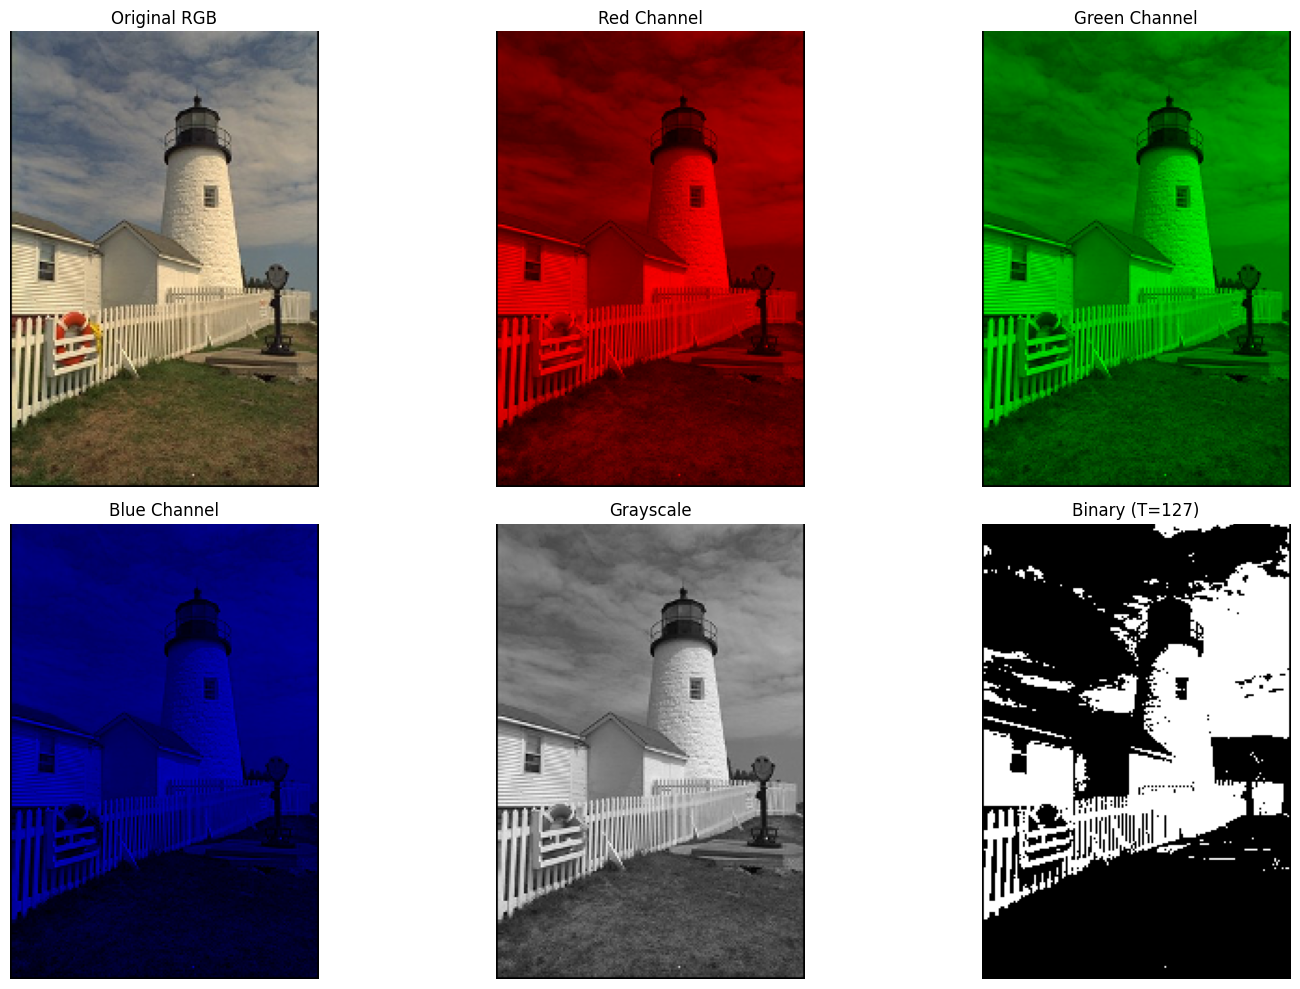

In [8]:
titles = [
    "Original RGB",
    "Red Channel",
    "Green Channel",
    "Blue Channel",
    "Grayscale",
    f"Binary (T={threshold_value})"
]
images = [image_rgb, red_channel, green_channel, blue_channel, gray, binary]

plt.figure(figsize=(16, 10))
for i in range(6):
    plt.subplot(2, 3, i+1)
    if i < 4:
        plt.imshow(images[i])  # RGB channels
    else:
        plt.imshow(images[i], cmap='gray')  # Grayscale or binary
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()